In [ ]:
import kagglehub
from google.colab import files
files.upload()  # selecione o arquivo kaggle.json

# Cria a pasta .kaggle e move o arquivo
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json  # garante permissões seguras

# Download
path = kagglehub.dataset_download("newra008/lung-mask-image-dataset")

print("Path to dataset files:", path)

Saving kaggle.json to kaggle.json


100%|██████████| 2.59G/2.59G [00:33<00:00, 84.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/newra008/lung-mask-image-dataset/versions/3


In [ ]:
!ls /root/.cache/kagglehub/datasets/newra008/lung-mask-image-dataset/versions/3

ChestXray


In [ ]:
from pathlib import Path

base_dir = Path("/root/.cache/kagglehub/datasets/newra008/lung-mask-image-dataset/versions/3/ChestXray")

def get_image_mask_pairs(split):
    image_dir = base_dir / split / "image"
    mask_dir = base_dir / split / "mask"

    image_paths = sorted(image_dir.glob("*.png"))
    mask_paths = sorted(mask_dir.glob("*.jpeg"))

    # Extrair o índice numérico do nome
    image_dict = {p.stem.replace("cxrimage_", ""): p for p in image_paths}
    mask_dict = {p.stem.replace("cxrmask_", ""): p for p in mask_paths}

    common_ids = sorted(set(image_dict.keys()) & set(mask_dict.keys()))

    image_paths = [image_dict[i] for i in common_ids]
    mask_paths = [mask_dict[i] for i in common_ids]

    print(f"{split}: {len(image_paths)} pares encontrados.")
    return image_paths, mask_paths

train_img, train_mask = get_image_mask_pairs('train')
val_img, val_mask = get_image_mask_pairs('val')
test_img, test_mask = get_image_mask_pairs('test')


train: 16932 pares encontrados.
val: 2117 pares encontrados.
test: 2116 pares encontrados.


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class LungSegmentationDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform_img=None, transform_mask=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform_img = transform_img
        self.transform_mask = transform_mask

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx]).convert("L")

        if self.transform_img:
            image = self.transform_img(image)
        if self.transform_mask:
            mask = self.transform_mask(mask)

        mask = (mask > 0).float()
        return image, mask


In [ ]:
transform_img = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

transform_mask = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

train_dataset = LungSegmentationDataset(train_img, train_mask, transform_img, transform_mask)
val_dataset = LungSegmentationDataset(val_img, val_mask, transform_img, transform_mask)
test_dataset = LungSegmentationDataset(test_img, test_mask, transform_img, transform_mask)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4)
test_loader = DataLoader(test_dataset, batch_size=4)


In [ ]:
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()
        self.down1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.output = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        d1 = self.down1(x)
        p1 = self.pool1(d1)
        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        b = self.bottleneck(p2)

        u2 = self.up2(b)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv2(u2)

        u1 = self.up1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.conv1(u1)

        return torch.sigmoid(self.output(u1))


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [ ]:
def train(model, train_loader, val_loader, criterion, optimizer, num_epochs=5):
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item()

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss/len(train_loader):.4f}, Val Loss: {val_loss/len(val_loader):.4f}")


In [ ]:
train(model, train_loader, val_loader, criterion, optimizer, num_epochs=10)

Epoch 1/10, Train Loss: 0.1072, Val Loss: 0.0806
Epoch 2/10, Train Loss: 0.0445, Val Loss: 0.0558
Epoch 3/10, Train Loss: 0.0368, Val Loss: 0.0589
Epoch 4/10, Train Loss: 0.0328, Val Loss: 0.0615
Epoch 5/10, Train Loss: 0.0305, Val Loss: 0.0497
Epoch 6/10, Train Loss: 0.0289, Val Loss: 0.0432
Epoch 7/10, Train Loss: 0.0277, Val Loss: 0.0458
Epoch 8/10, Train Loss: 0.0260, Val Loss: 0.0470
Epoch 9/10, Train Loss: 0.0250, Val Loss: 0.0507
Epoch 10/10, Train Loss: 0.0245, Val Loss: 0.0558


In [ ]:
import matplotlib.pyplot as plt

def show_sample(model, dataset, index=0):
    model.eval()
    image, mask = dataset[index]
    image_input = image.unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(image_input).squeeze().cpu().numpy()

    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].imshow(image.permute(1, 2, 0))
    axs[0].set_title("Imagem")
    axs[1].imshow(mask.squeeze(), cmap='gray')
    axs[1].set_title("Máscara Real")
    axs[2].imshow(pred > 0.5, cmap='gray')
    axs[2].set_title("Predição")
    plt.show()


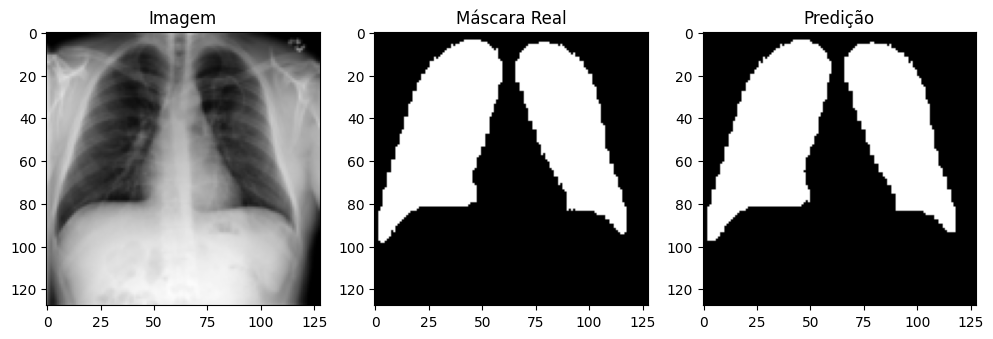

In [ ]:
show_sample(model, test_dataset, index=3)
